In [2]:
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

In [3]:
digits = load_digits()
print(digits.data.shape)

(1797, 64)


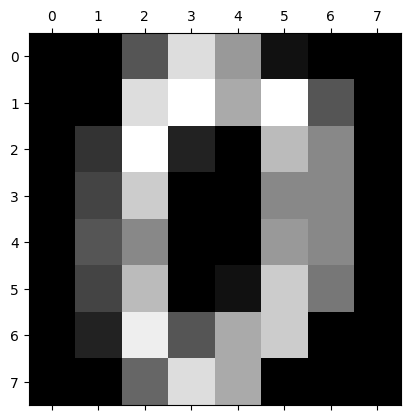

In [4]:
plt.matshow(digits.images[0], cmap="gray")
plt.show()

In [5]:
import torch

from ml.DigitRecognizer import DigitRecognizer

model_data = torch.load('../models/model_20251218_160200.pth')

model = DigitRecognizer()
model.load_state_dict(model_data['model_state_dict'])
model.eval()

DigitRecognizer(
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

True: 3, Predicted: 5


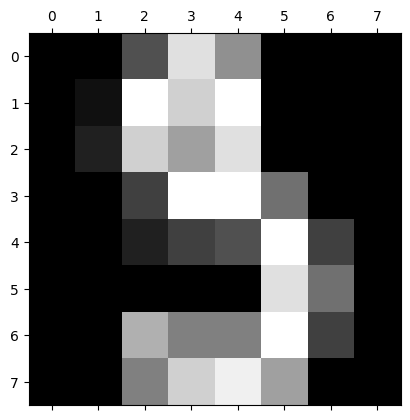

True: 7, Predicted: 9


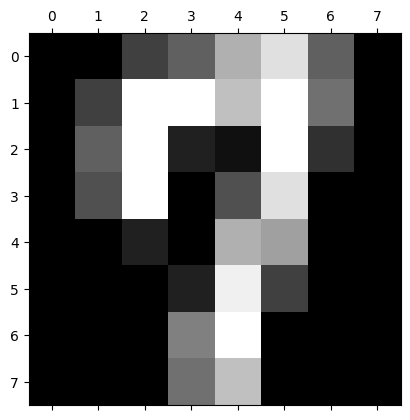

True: 6, Predicted: 4


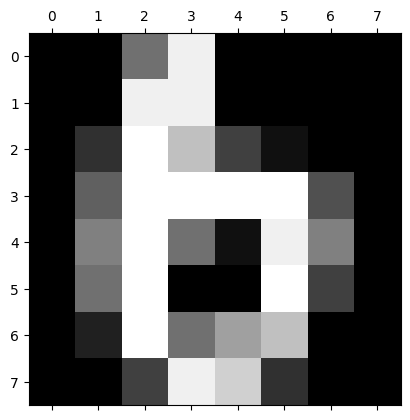

True: 8, Predicted: 5


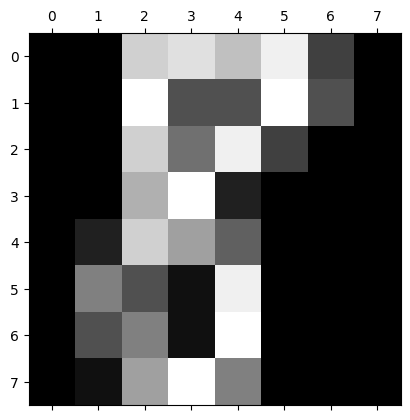

True: 9, Predicted: 7


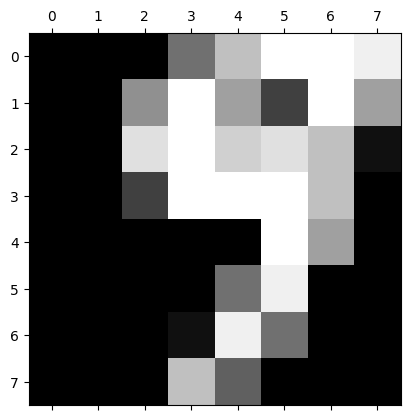

True: 9, Predicted: 8


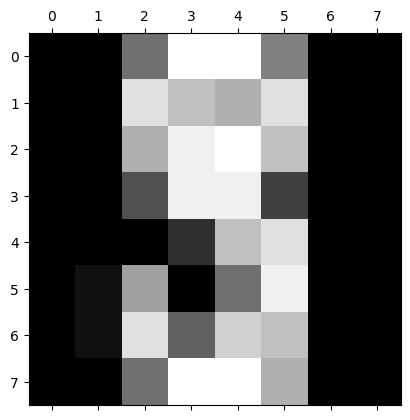

In [10]:
X, y = digits.data, digits.target

with torch.no_grad():
    for i in range(X.shape[0]):
        input_tensor = torch.tensor(X[i], dtype=torch.float32).unsqueeze(0)
        output = model(input_tensor)
        predicted = torch.argmax(output, dim=1).item()
        
        if predicted != y[i]:
            print(f"True: {y[i]}, Predicted: {predicted}")
            plt.matshow(digits.images[i], cmap="gray")
            plt.show()


        if i % 100 == 0:
            plt.imsave(f"../data/digit_{i}_pred_{predicted}.png", digits.images[i], cmap="gray")